# Graphing Films Categorized by Language

## Imports and helper functions

In [1]:
# Processing data 
import pandas as pd

# For Plotly
import plotly.express as px
import plotly.tools as tools
import plotly.graph_objects as go

# Jupyter magic for helper code
%run helpers.ipynb

## Create status column

Similarly to the other graphing code, we want to categorize films by nominee status, so we create a `Status` column and concatenate all films.

In [2]:
oscar_with_imdb, imdb_non_oscar = read_data('oscar_with_imdb.csv', 'imdb_non_oscar.csv')

oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row == True else 'Nominated')
imdb_non_oscar['Status'] = 'No nomination'

We filter on the columns to be used in the final plot and concatenate the dataframes of films in the Oscar and IMDb dataframes. We drop rows with missing language data, as we don't want to include them in the final graphs.

In [3]:
columns = ['title', 'rating', 'meta_score', 'votes', 'languages', 'Status']

oscars_df = oscar_with_imdb[columns]
imdb_df = imdb_non_oscar[columns]

graph_df = pd.concat([oscars_df[columns], imdb_df[columns]], axis=0)
graph_df.dropna(subset=['languages'], inplace=True)
# Remove films that were in both datsets
# graph_df = graph_df.drop_duplicates(subset=['title'])

Films in the dataset are formatted as strings, but in a format similar to a list, like this:
['English', 'Spanish', 'French']

Our understanding is that the first language is the film's language, and the next entries are translations for subtitles. We want to parse the first language using a helper function we created called `get_languages`, which uses the AST library to return a list of data and a single language, which we then use a lambda to apply to every dataframe row. Some films have the language field as `[None]`, which we drop, as well as any blank rows, along with films with English as the primary language.

In [4]:
graph_df['language'] = graph_df['languages'].apply(lambda x: get_language(x))
filtered = graph_df[~graph_df['language'].isin(['English', 'None', '', None])]

## Get frequent langauges

The variable `topn` can be assigned a number to explore the top "n" non-English languages that films appear in. We set it to 20 for this exploration, and then filter the data by creating an index of top languages and then creating a new dataframe with exclusively films in those languages, called `top_n_df`.

We then group `top_n_df` by language and award status while adding three new fields:
1. The mean rating of films for each language and award status
2. The total votes of films for each language and award status
3. The total films in each language and award status

In [5]:
topn = 20
most_frequent_langs = (
    filtered['language']
    .value_counts()
    .nlargest(topn)
    .index
)

top_n_df = filtered[filtered['language'].isin(most_frequent_langs)]

top_n_grouped = top_n_df.groupby(['language', 'Status']).agg(
    avg_rating=('rating', 'mean'),
    sum_votes=('votes', 'sum'),
    total_films=('language', 'size')
).reset_index()

# Convert the sum votes column from a float to an integer for graphing
top_n_grouped['sum_votes'] = top_n_grouped['sum_votes'].astype(int)

This is what `top_n_df` looks like, sorted alphabetically

In [6]:
top_n_grouped.head(10)

,language,Status,avg_rating,sum_votes,total_films
0,Arabic,No nomination,6.940571,329814,175
1,Arabic,Nominated,7.690909,462200,11
2,Cantonese,No nomination,6.364667,2767840,450
3,Cantonese,Nominated,6.800000,24000,1
4,Czech,No nomination,6.927149,264753,221
5,Czech,Nominated,7.580000,35000,5
6,Czech,Winner,7.650000,31000,2
7,Danish,No nomination,6.239185,1007264,319
8,Danish,Nominated,7.350000,777365,12
9,Danish,Winner,7.700000,288000,4


## Creating the plots
With all films are grouped by language and status, we then create the three plots of data to explore

In [7]:
all_figs = [None, None, None]

### Plotting the average IMDb rating for films in each award category by language
We add the `avg_rating` column to a Plotly bar figure and use language as the x-axis to show the average IMDb rating in each status category for each language.

In [8]:
fig_avgs = px.bar(
    top_n_grouped,
    x='language',
    y='avg_rating',
    color='Status',
    barmode='group',
    title='Average IMDb Rating by Language and Award Status',
    color_discrete_sequence=['#cd7f32', '#c0c0c0', '#fcc200']
)

fig_avgs.update_traces(hovertemplate='%{y:.1f}<extra></extra>')
fig_avgs.update_layout(xaxis_title='Language', yaxis_title='Average IMDb Rating')

all_figs[0] = fig_avgs

### Plotting the total films in each award category by language
We add the `total_films` column to a Plotly bar figure and use language as the x-axis to show the total films in each status category for each language.

In [9]:
fig_counts = px.bar(
    top_n_grouped,
    x='language',
    y='total_films',
    color='Status',
    barmode='group',
    title='Number of Films by Language and Award Status',
    color_discrete_sequence=['#cd7f32', '#c0c0c0', '#fcc200']
)

fig_counts.update_traces(hovertemplate='%{y:,d}<extra></extra>')
fig_counts.update_yaxes(type='log', dtick=1)
fig_counts.update_layout(xaxis_title='Language', yaxis_title='Number of Films (Log scaled)')

all_figs[1] = fig_counts

### Plotting the total films in each award category by language
We add the `sum_votes` column to a Plotly bar figure and use language as the x-axis to show the total number of votes per status category for each language.

In [10]:
fig_votes = px.bar(
    top_n_grouped,
    x='language',
    y='sum_votes',
    color='Status',
    barmode='group',
    title='Total Votes by Language and Status',
    color_discrete_sequence=['#cd7f32', '#c0c0c0', '#fcc200']
)

fig_votes.update_traces(hovertemplate='%{y:,d}<extra></extra>')
fig_votes.update_yaxes(type='log', dtick=1)
fig_votes.update_layout(xaxis_title='Language', yaxis_title='Total Votes (Log scaled)')

all_figs[2] = fig_votes

### Display all charts

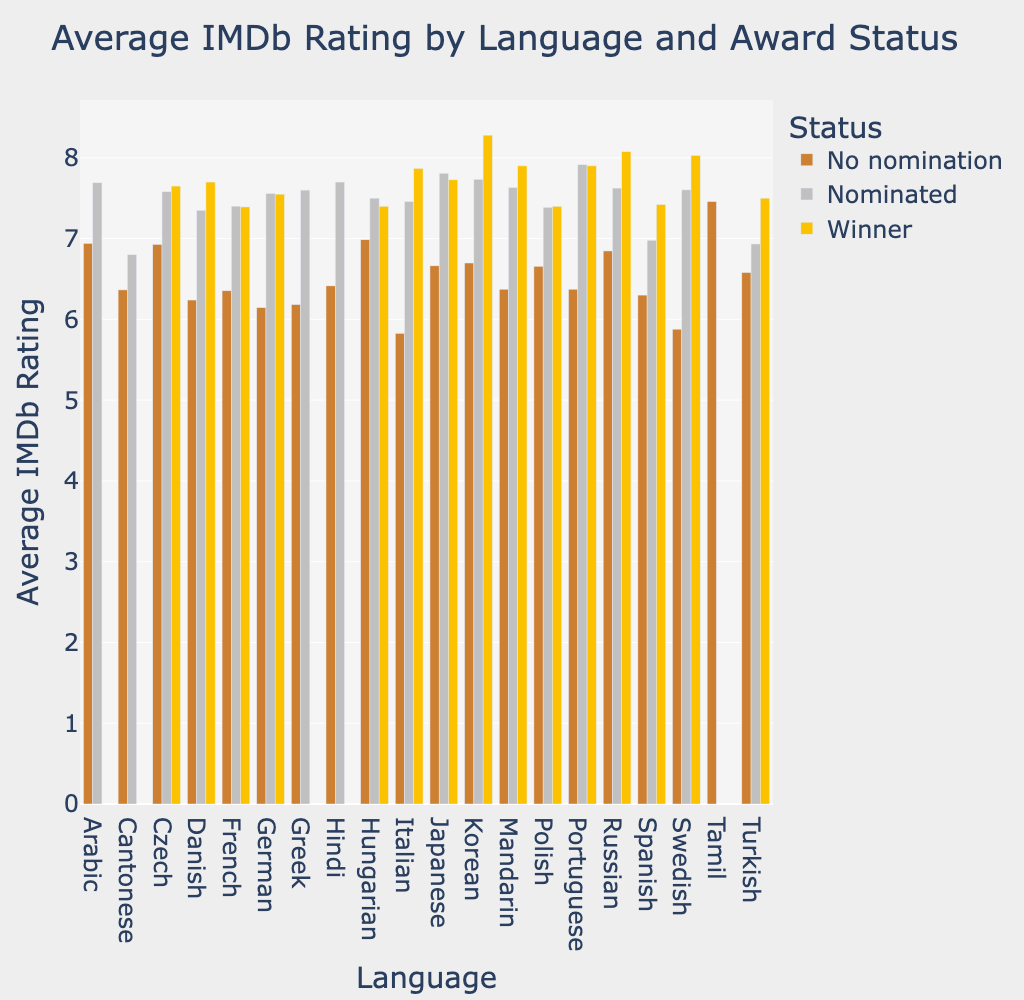

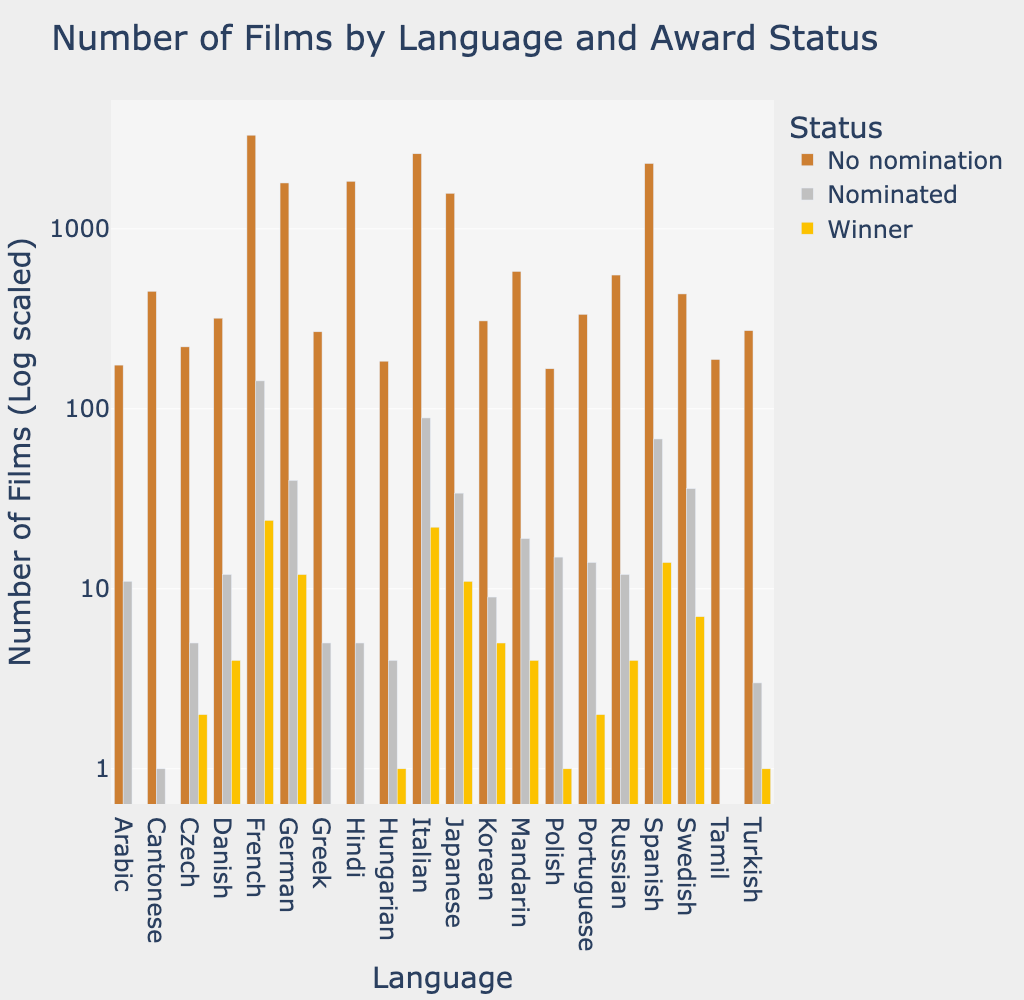

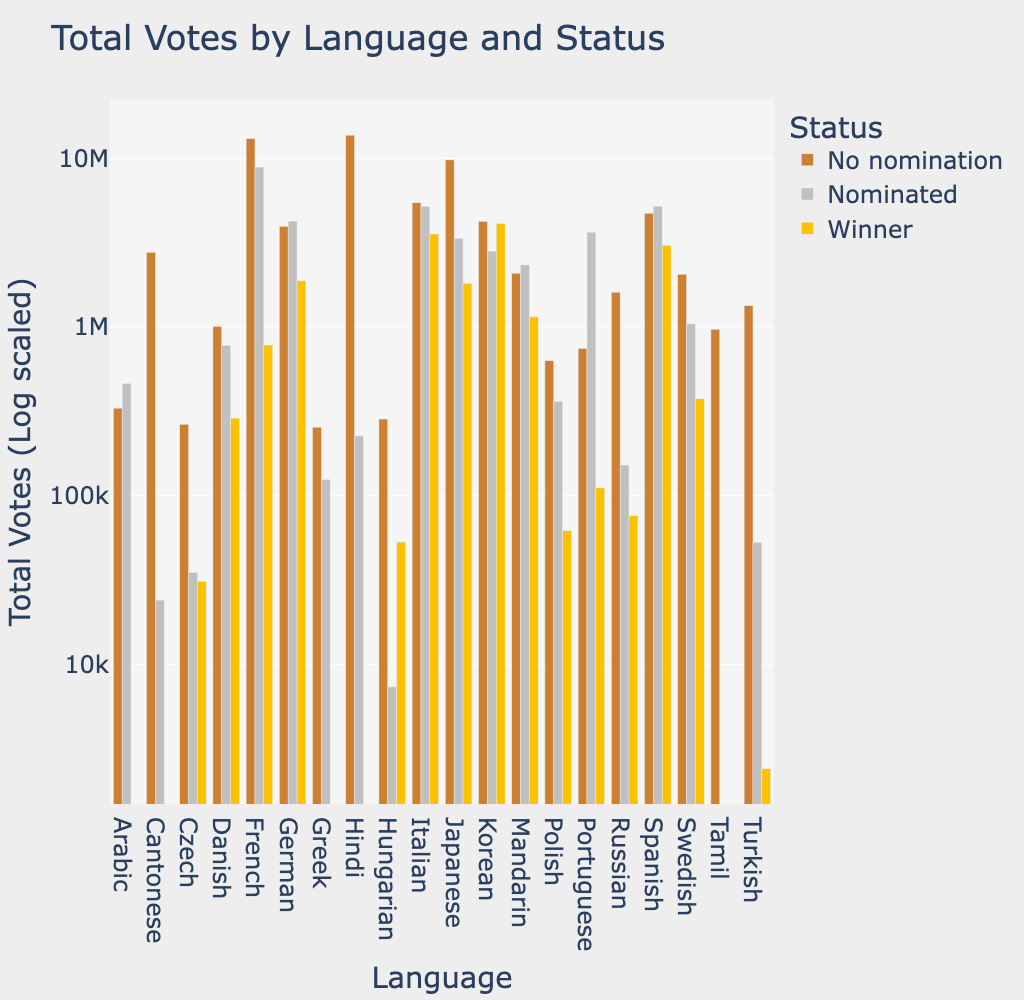

In [11]:
for fig in all_figs:
    fig.update_layout(height=1000, font=dict(size=24), legend=dict(font=dict(size=24)))
    fig.update_layout(
        paper_bgcolor='#eeeeee',
        plot_bgcolor='#f5f5f5',
    )

    fig.show(config={'displayModeBar': False})

## Further analysis

### Out of curiosity, there is one film for Hungarian, Polish, and Turkish data with an Oscar:

In [12]:
language_winners = filtered[filtered['Status'] == 'Winner']
hungarian_winner = language_winners[language_winners['language'] == 'Hungarian'].iloc[0]['title']
polish_winner = language_winners[language_winners['language'] == 'Polish'].iloc[0]['title']
turkish_winner = language_winners[language_winners['language'] == 'Turkish'].iloc[0]['title']

print(f'Hungarian Film: {hungarian_winner}\nPolish Film: {polish_winner}\nTurkish Film: {turkish_winner}')

Hungarian Film: Son of Saul
Polish Film: Ida
Turkish Film: Journey of Hope


In [13]:
fig_avgs.write_html('output/Language and Ratings.html')
fig_counts.write_html('output/Language and Counts.html')
fig_votes.write_html('output/Language and Votes.html')

### How many times did films appear in other languages by status?

In [14]:
all_langs = filtered.groupby(['language', 'Status']).agg(
    avg_rating=('rating', 'mean'),
    sum_votes=('votes', 'sum'),
    total_films=('language', 'size')
).reset_index()


#### Total non-English films in the IMDb yearly top 500

In [15]:
print('Total non-English films in the IMDb yearly top 500:', np.sum(all_langs['total_films']))

Total non-English films in the IMDb yearly top 500: 20657


#### Total non-English films in the IMDb yearly top 500 with an Academy Award or nomination

In [16]:
academy_films = all_langs[all_langs['Status'] != 'No nomination']

In [17]:
print(np.sum(academy_films['total_films']))

708


#### Total non-English films in the IMDb yearly top 500 without an Academy Award nomination

In [18]:
non_nominated_by_lang = all_langs[all_langs['Status'] == 'No nomination']

In [19]:
print(np.sum(non_nominated_by_lang['total_films']))

19949
